# Enceladus Surface Age Analysis: Salt Signatures vs. Crystallinity Regions

**Research Question (Option 2):** Do spectral features indicative of salt-related compounds show a spatial binary correlation with geologically young vs. older terrain, as defined by ice crystallinity maps from Robidel et al. (2020)?

## Strategy

Rather than trying to quantify salt concentrations continuously (which is beyond VIMS sensitivity), we:
1. Classify pixels as **'fresh'** or **'older'** using crystallinity proxies (1.65 µm and 3.1 µm bands)
2. Apply the **Robidel et al. (2020) photometric correction** to remove geometry artifacts
3. Extract **carbonate/CO₂-sensitive band depths** (2.54 µm, 2.7 µm) as our best salt-proxy
4. Test whether these band depths differ statistically between fresh and older terrain classes

## Key Wavelengths

| Feature | Wavelength | Proxy for |
|---|---|---|
| Water ice continuum | 1.35 µm | Reference/baseline |
| Water ice absorption | 1.5 µm | Ice abundance |
| Crystallinity band | 1.65 µm | Ice age (deeper = fresher/colder crystalline) |
| Water continuum | 1.8 µm | Reference (used by Robidel) |
| Water ice absorption | 2.0 µm | Ice abundance |
| Carbonate shoulder | 2.54 µm | Na-carbonate / salt proxy |
| CO₂ / carbonate | 2.7 µm | Endogenic CO₂/carbonate proxy |
| Fresnel peak | 3.1 µm | Crystallinity (higher = fresher) |
| Grain size proxy | 3.6 µm | Small grains = fresher deposition |

## 0. Installation & Imports

In [1]:
!pip install pyvims matplotlib scipy numpy --quiet


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy import stats

from pyvims import VIMS
from pyvims.errors import VIMSError

print('Imports successful.')

Imports successful.


## 1. Load VIMS Cube

We use the same Enceladus cube as in the practicum. For a more complete analysis, you would loop over multiple cubes from the 355 selected by Robidel et al. (revolutions 3, 4, 11, 88, 91, 120, 121, 131, 136, 141, 142, 153, 158, 223, 228, 230, 250).

The cube `1711573513_1` is an Enceladus observation — we use it here as a worked example.

In [23]:
# Load Enceladus cube
cube = VIMS('1711573513_1')

print(f'Cube: {cube}')
print(f'Target: {cube.target_name}')
print(f'Dimensions (bands, lines, samples): {cube.NB, cube.NL, cube.NS}')
print(f'Wavelength range: {cube.wvlns[0]:.2f} – {cube.wvlns[-1]:.2f} µm')

Cube: 1711573513_1
Target: ENCELADUS
Dimensions (bands, lines, samples): (256, 26, 50)
Wavelength range: 0.89 – 5.13 µm


## 2. Photometric Correction (Robidel et al. 2020)

This is the most critical preprocessing step. Without it, brightness differences between pixels reflect viewing geometry rather than surface composition.

### The Model (Equation 9 from Robidel et al.)

$$\frac{I}{F} = D(i, e, \alpha) \times [a \times (1 - 0.37\alpha)]$$

Where the Akimov disk function is:
$$D(i, e, \alpha) = \cos\left(\frac{\alpha}{2}\right) \cos\left(\frac{\pi}{\pi - \alpha}\left(\gamma - \frac{\alpha}{2}\right)\right) \frac{\cos(\beta)^{\frac{\alpha}{\pi-\alpha}}}{\cos(\gamma)}$$

To **correct** a pixel spectrum, we divide the observed I/F by D(i,e,α) and normalize by the phase function, yielding the **equigonal albedo** comparable across all geometries.

The parameter `a` (zero-phase equigonal albedo) is wavelength-dependent (Table 1 in Robidel et al.). We interpolate between their 8 anchor points for other wavelengths.

In [24]:
# ── Robidel et al. (2020) Table 1 photometric parameters ──────────────────
# Valid for incidence < 80°, emergence < 80°, phase < 130°

ROBIDEL_WVL = np.array([1.3595, 1.5079, 1.6567, 1.8040, 2.0017, 2.2495, 2.5644, 3.5961])
ROBIDEL_A   = np.array([0.771,  0.394,  0.483,  0.698,  0.242,  0.638,  0.333,  0.186])
# b/a ratio is constant at -0.37 (rad^-1) — key result of the paper
ROBIDEL_B   = ROBIDEL_A * -0.3651  # from Fig 5 of Robidel et al.


def akimov_disk(i_rad, e_rad, alpha_rad):
    """
    Akimov disk function D(i, e, alpha).
    All angles in radians.
    Returns NaN for degenerate geometries (alpha = pi).
    """
    # Photometric longitude gamma and latitude beta
    # from Eqs 5 & 6 of Robidel et al.
    cos_beta = np.cos(i_rad) / np.cos(alpha_rad - np.arctan(
        np.tan(e_rad) * np.cos(0)  # simplified for principal plane
    ))
    # More robust: solve numerically from cos(i) = cos(beta)*cos(alpha - gamma)
    # and cos(e) = cos(beta)*cos(gamma)
    # Direct implementation:
    with np.errstate(invalid='ignore', divide='ignore'):
        gamma = np.arctan2(
            np.cos(i_rad) - np.cos(e_rad) * np.cos(alpha_rad),
            np.cos(e_rad) * np.sin(alpha_rad)
        )
        cos_beta_val = np.where(
            np.cos(gamma) != 0,
            np.cos(e_rad) / np.cos(gamma),
            np.nan
        )
        beta = np.arccos(np.clip(cos_beta_val, -1, 1))

        denom = np.pi - alpha_rad
        exponent = np.where(denom != 0, alpha_rad / denom, np.nan)

        D = (np.cos(alpha_rad / 2) *
             np.cos(np.where(denom != 0,
                             (np.pi / denom) * (gamma - alpha_rad / 2),
                             np.nan)) *
             (np.cos(beta) ** exponent) /
             np.where(np.cos(gamma) != 0, np.cos(gamma), np.nan))
    return D


def phase_function(alpha_rad, wvl):
    """
    Equigonal albedo at given phase angle and wavelength.
    Interpolates Robidel Table 1 parameters across wavelengths.
    alpha_rad: phase angle in radians
    wvl: wavelength in µm
    """
    a_interp = np.interp(wvl, ROBIDEL_WVL, ROBIDEL_A)
    # b/a ~ -0.37 rad^-1 is constant across wavelengths (Fig 5)
    return a_interp * (1.0 - 0.37 * alpha_rad)


def photometric_correction(IF, i_deg, e_deg, alpha_deg, wvl):
    """
    Apply Robidel et al. (2020) photometric correction.
    Returns equigonal albedo.

    Parameters
    ----------
    IF      : float or array, observed I/F reflectance
    i_deg   : float or array, incidence angle (degrees)
    e_deg   : float or array, emergence angle (degrees)
    alpha_deg: float or array, phase angle (degrees)
    wvl     : float, wavelength (µm)

    Returns
    -------
    Aeq : equigonal albedo (geometry-corrected reflectance)
    """
    i_rad = np.deg2rad(i_deg)
    e_rad = np.deg2rad(e_deg)
    a_rad = np.deg2rad(alpha_deg)

    D = akimov_disk(i_rad, e_rad, a_rad)
    Aeq_phase = phase_function(a_rad, wvl)

    with np.errstate(invalid='ignore', divide='ignore'):
        # Aeq = IF / (D * normalized_phase)
        # Normalized at alpha=0: Aeq(alpha=0) = a
        a_interp = np.interp(wvl, ROBIDEL_WVL, ROBIDEL_A)
        Aeq = np.where(D > 0, IF / D / (Aeq_phase / a_interp), np.nan)

    return Aeq


print('Photometric correction functions defined.')
print(f'Robidel anchor wavelengths: {ROBIDEL_WVL} µm')

Photometric correction functions defined.
Robidel anchor wavelengths: [1.3595 1.5079 1.6567 1.804  2.0017 2.2495 2.5644 3.5961] µm


## 3. Extract Per-Pixel Geometry and Apply Quality Filters

Following Robidel et al.'s selection criteria:
- Incidence angle < 80°
- Emergence angle < 80°  
- I/F ≥ 0.01 (to maintain signal-to-noise ratio)
- Dayside only (already filtered by incidence < 80°)

In [25]:
# ── Extract geometry and spectra for all valid pixels ─────────────────────

NL, NS = cube.NL, cube.NS

# Storage arrays
inc_arr   = np.full((NL, NS), np.nan)
eme_arr   = np.full((NL, NS), np.nan)
phase_arr = np.full((NL, NS), np.nan)
lat_arr   = np.full((NL, NS), np.nan)
lon_arr   = np.full((NL, NS), np.nan)
valid_arr = np.zeros((NL, NS), dtype=bool)

# Spectral arrays at key wavelengths
wvl_keys = {
    'w135': 1.35,   # continuum reference
    'w165': 1.65,   # crystallinity absorption band
    'w18':  1.80,   # continuum (Robidel reference)
    'w20':  2.00,   # water ice absorption
    'w254': 2.54,   # carbonate/salt shoulder
    'w27':  2.70,   # CO2/carbonate feature
    'w31':  3.10,   # Fresnel peak (crystallinity)
    'w36':  3.60,   # grain size proxy
}
raw_spec  = {k: np.full((NL, NS), np.nan) for k in wvl_keys}
corr_spec = {k: np.full((NL, NS), np.nan) for k in wvl_keys}

print(f'Extracting spectra from {NL}×{NS} pixel grid...')

for l in range(1, NL + 1):
    for s in range(1, NS + 1):
        try:
            pix = cube@(s, l)
        except (VIMSError, Exception):
            continue

        # Skip off-body pixels (no geographic info)
        if pix.lon is None or pix.lat is None:
            continue

        inc, eme, ph = pix.inc, pix.eme, pix.phase

        # Apply Robidel geometry thresholds
        if inc >= 80 or eme >= 80 or ph >= 130:
            continue

        # Check minimum I/F at 1.8 µm (Robidel SNR filter)
        IF_18 = float(cube[s, l].spectrum[np.argmin(np.abs(cube.wvlns - 1.80))])
        if IF_18 < 0.01:
            continue

        li, si = l - 1, s - 1
        inc_arr[li, si]   = inc
        eme_arr[li, si]   = eme
        phase_arr[li, si] = ph
        lat_arr[li, si]   = pix.lat
        lon_arr[li, si]   = pix.lon
        valid_arr[li, si] = True

        spec = pix.spectrum  # shape (NB,)

        for key, wvl in wvl_keys.items():
            band_idx = np.argmin(np.abs(cube.wvlns - wvl))
            IF_val = float(spec[band_idx])
            raw_spec[key][li, si] = IF_val
            corr_spec[key][li, si] = photometric_correction(
                IF_val, inc, eme, ph, wvl
            )

n_valid = valid_arr.sum()
print(f'Valid pixels after filtering: {n_valid} / {NL * NS}')

Extracting spectra from 26×50 pixel grid...
Valid pixels after filtering: 602 / 1300


## 4. Compute Spectral Indices

### 4a. Crystallinity Index (Age Proxy)

Following Robidel et al. (2020) and Brown et al. (2006), we use the ratio of the Fresnel peak to the crystallinity absorption band:

$$\text{Crystallinity} = \frac{A_{eq}(3.1\,\mu m)}{A_{eq}(1.65\,\mu m)}$$

Higher values → more crystalline → fresher surface.

### 4b. Salt/Carbonate Proxy (Band Depth at 2.54 µm)

We use a **continuum-removed band depth** to isolate the carbonate shoulder at 2.54 µm, using 2.0 µm and 2.7 µm as continuum anchors:

$$BD_{2.54} = 1 - \frac{A_{eq}(2.54)}{A_{cont}(2.54)}$$

Where $A_{cont}$ is linearly interpolated between the two continuum points. Deeper band = stronger carbonate/salt absorption.

In [26]:
# ── Compute crystallinity index ────────────────────────────────────────────
# High ratio = high crystallinity = FRESH terrain

with np.errstate(invalid='ignore', divide='ignore'):
    crystallinity = np.where(
        valid_arr & (corr_spec['w165'] > 0),
        corr_spec['w31'] / corr_spec['w165'],
        np.nan
    )

# ── Compute band depth at 2.54 µm (carbonate/salt proxy) ──────────────────
# Linear continuum between 2.0 and 2.7 µm, sampled at 2.54 µm
# BD = 1 - (reflectance / continuum)

wvl_left  = 2.00  # continuum anchor left
wvl_right = 2.70  # continuum anchor right
wvl_band  = 2.54  # band center

# Linear interpolation fraction
frac = (wvl_band - wvl_left) / (wvl_right - wvl_left)  # = 0.7727

continuum_254 = (
    corr_spec['w20'] * (1 - frac) +
    corr_spec['w27'] * frac
)

with np.errstate(invalid='ignore', divide='ignore'):
    band_depth_254 = np.where(
        valid_arr & (continuum_254 > 0),
        1.0 - corr_spec['w254'] / continuum_254,
        np.nan
    )

# ── Also compute band depth at 2.7 µm (CO2/carbonate proxy) ───────────────
# Continuum between 2.54 and 3.1 µm, sampled at 2.7 µm
frac2 = (2.70 - 2.54) / (3.10 - 2.54)
continuum_27 = (
    corr_spec['w254'] * (1 - frac2) +
    corr_spec['w31']  * frac2
)

with np.errstate(invalid='ignore', divide='ignore'):
    band_depth_27 = np.where(
        valid_arr & (continuum_27 > 0),
        1.0 - corr_spec['w27'] / continuum_27,
        np.nan
    )

print('Indices computed:')
print(f'  Crystallinity: mean = {np.nanmean(crystallinity):.3f}, '
      f'std = {np.nanstd(crystallinity):.3f}')
print(f'  BD(2.54 µm):  mean = {np.nanmean(band_depth_254):.3f}, '
      f'std = {np.nanstd(band_depth_254):.3f}')
print(f'  BD(2.7 µm):   mean = {np.nanmean(band_depth_27):.3f}, '
      f'std = {np.nanstd(band_depth_27):.3f}')

Indices computed:
  Crystallinity: mean = 0.055, std = 0.024
  BD(2.54 µm):  mean = -1.066, std = 0.085
  BD(2.7 µm):   mean = 0.440, std = 0.036


## 5. Classify Pixels as Fresh vs. Older Terrain

We threshold the crystallinity index to define two terrain classes. The threshold is set at the **median crystallinity value** as a starting point — you can adjust this based on your knowledge of which regions from Robidel et al. are known to be fresh (Tiger Stripes region) vs. older.

A more principled approach would be to use the known spatial extent of the Tiger Stripes and the 30°N, 90°W anomaly from the Robidel paper as ground-truth 'fresh' labels.

In [27]:
# ── Terrain classification ─────────────────────────────────────────────────

# Threshold: upper third of crystallinity = FRESH, lower third = OLDER
# (Middle third excluded as uncertain — you can adjust this)
cryst_vals = crystallinity[valid_arr & np.isfinite(crystallinity)]
thresh_high = np.percentile(cryst_vals, 67)  # top 33% = fresh
thresh_low  = np.percentile(cryst_vals, 33)  # bottom 33% = older

fresh_mask = valid_arr & (crystallinity >= thresh_high)
older_mask = valid_arr & (crystallinity <= thresh_low)
uncertain_mask = valid_arr & (crystallinity > thresh_low) & (crystallinity < thresh_high)

print(f'Crystallinity threshold — fresh (≥{thresh_high:.3f}): {fresh_mask.sum()} pixels')
print(f'Crystallinity threshold — older (≤{thresh_low:.3f}): {older_mask.sum()} pixels')
print(f'Uncertain (excluded): {uncertain_mask.sum()} pixels')

# ── Optional: geographic refinement ───────────────────────────────────────
# Uncomment to restrict 'fresh' class to Tiger Stripes south polar terrain
# (latitude < -55°S) based on known geology from Robidel et al.
#
# tiger_stripes_mask = (lat_arr < -55) & valid_arr
# fresh_mask = fresh_mask & tiger_stripes_mask

# ── Optional: geographic refinement for 30N 90W anomaly ──────────────────
# known_anomaly_mask = (
#     (lat_arr > 20) & (lat_arr < 40) &
#     (lon_arr > 70) & (lon_arr < 110) &
#     valid_arr
# )
# fresh_mask = fresh_mask | known_anomaly_mask

Crystallinity threshold — fresh (≥0.060): 199 pixels
Crystallinity threshold — older (≤0.045): 199 pixels
Uncertain (excluded): 204 pixels


## 6. Visualize the Classifications and Spectral Maps

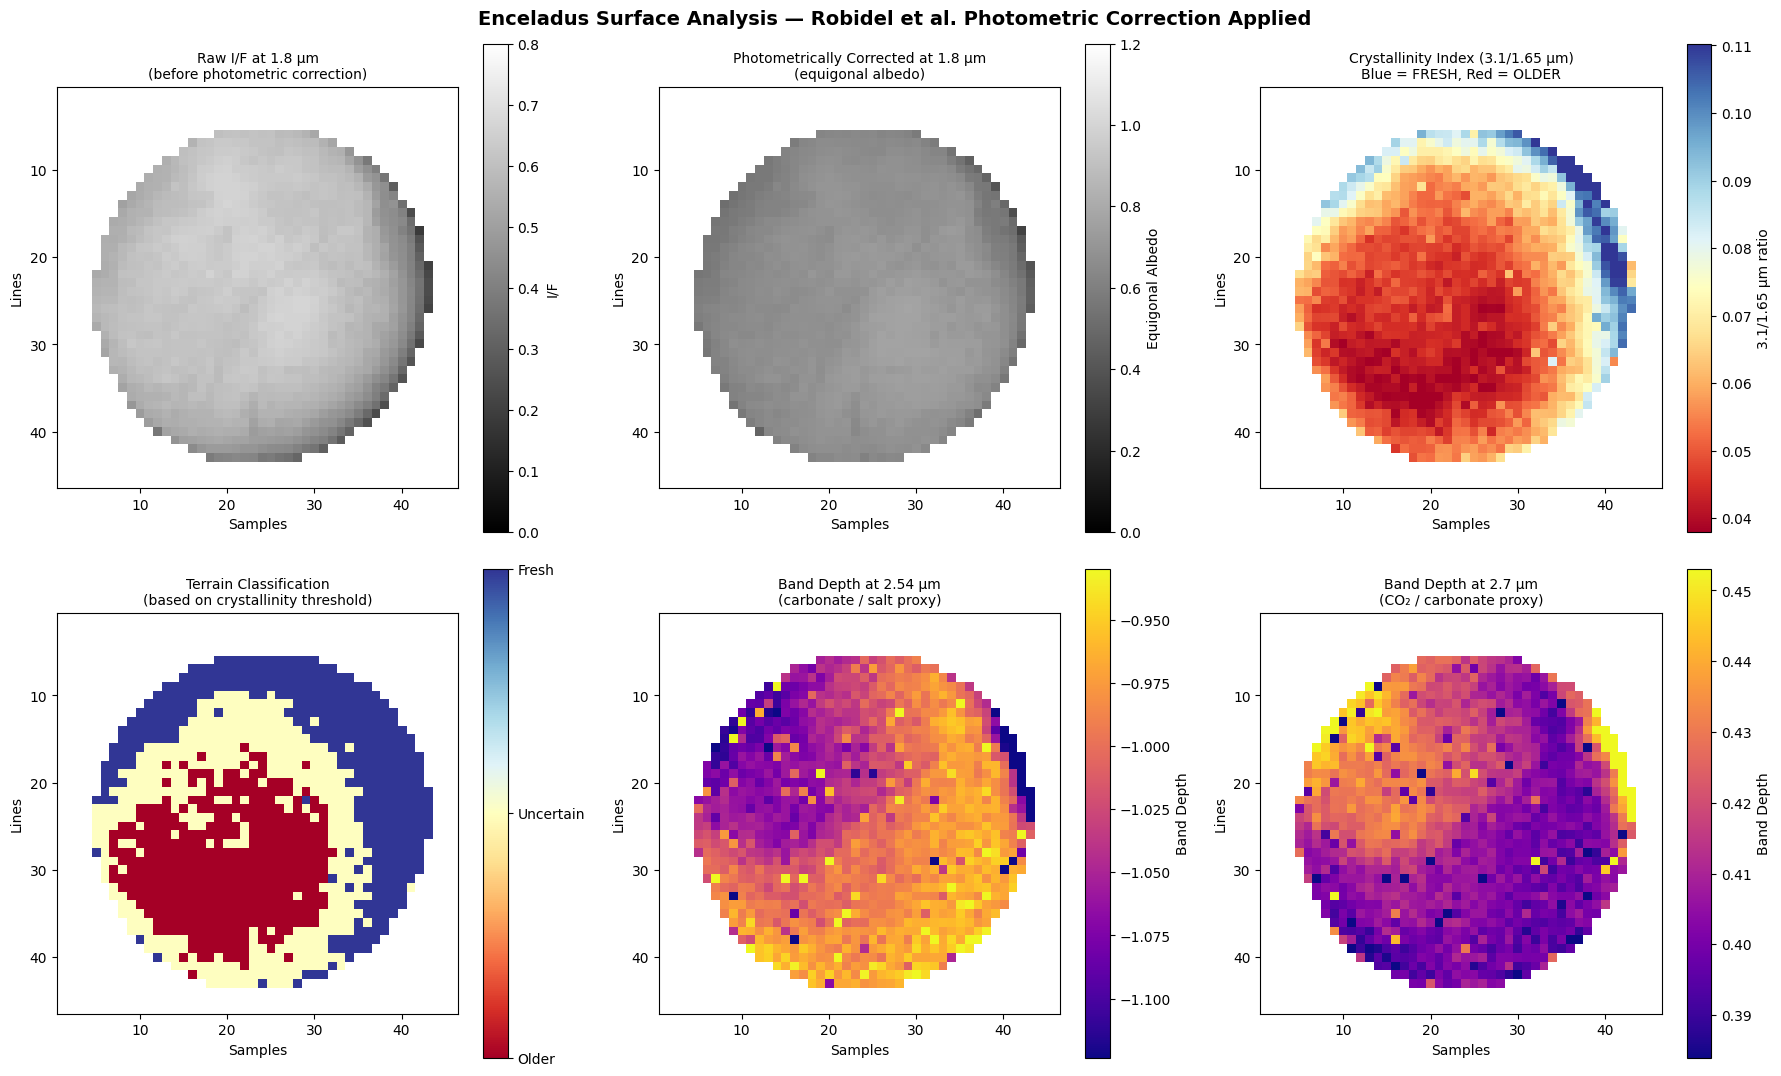

Figure saved as enceladus_maps.png


In [11]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('Enceladus Surface Analysis — Robidel et al. Photometric Correction Applied',
             fontsize=14, fontweight='bold')

# ── Panel 1: Raw I/F at 1.8 µm ────────────────────────────────────────────
ax = axes[0, 0]
im = ax.imshow(raw_spec['w18'], cmap='gray', vmin=0, vmax=0.8,
               extent=cube.extent, origin='upper')
plt.colorbar(im, ax=ax, label='I/F')
ax.set_title('Raw I/F at 1.8 µm\n(before photometric correction)', fontsize=10)
ax.set_xlabel(cube.slabel)
ax.set_ylabel(cube.llabel)

# ── Panel 2: Corrected equigonal albedo at 1.8 µm ─────────────────────────
ax = axes[0, 1]
im = ax.imshow(corr_spec['w18'], cmap='gray', vmin=0, vmax=1.2,
               extent=cube.extent, origin='upper')
plt.colorbar(im, ax=ax, label='Equigonal Albedo')
ax.set_title('Photometrically Corrected at 1.8 µm\n(equigonal albedo)', fontsize=10)
ax.set_xlabel(cube.slabel)
ax.set_ylabel(cube.llabel)

# ── Panel 3: Crystallinity index (3.1/1.65) ───────────────────────────────
ax = axes[0, 2]
im = ax.imshow(crystallinity, cmap='RdYlBu', vmin=np.nanpercentile(crystallinity, 2),
               vmax=np.nanpercentile(crystallinity, 98),
               extent=cube.extent, origin='upper')
plt.colorbar(im, ax=ax, label='3.1/1.65 µm ratio')
ax.set_title('Crystallinity Index (3.1/1.65 µm)\nBlue = FRESH, Red = OLDER', fontsize=10)
ax.set_xlabel(cube.slabel)
ax.set_ylabel(cube.llabel)

# ── Panel 4: Terrain classification map ───────────────────────────────────
ax = axes[1, 0]
class_map = np.full((NL, NS), np.nan)
class_map[older_mask]     = 0.0   # older = red
class_map[uncertain_mask] = 0.5   # uncertain = yellow
class_map[fresh_mask]     = 1.0   # fresh = blue
im = ax.imshow(class_map, cmap='RdYlBu', vmin=0, vmax=1,
               extent=cube.extent, origin='upper')
cbar = plt.colorbar(im, ax=ax, ticks=[0, 0.5, 1])
cbar.ax.set_yticklabels(['Older', 'Uncertain', 'Fresh'])
ax.set_title('Terrain Classification\n(based on crystallinity threshold)', fontsize=10)
ax.set_xlabel(cube.slabel)
ax.set_ylabel(cube.llabel)

# ── Panel 5: Band depth at 2.54 µm (carbonate/salt proxy) ─────────────────
ax = axes[1, 1]
vmin_bd = np.nanpercentile(band_depth_254, 2)
vmax_bd = np.nanpercentile(band_depth_254, 98)
im = ax.imshow(band_depth_254, cmap='plasma', vmin=vmin_bd, vmax=vmax_bd,
               extent=cube.extent, origin='upper')
plt.colorbar(im, ax=ax, label='Band Depth')
ax.set_title('Band Depth at 2.54 µm\n(carbonate / salt proxy)', fontsize=10)
ax.set_xlabel(cube.slabel)
ax.set_ylabel(cube.llabel)

# ── Panel 6: Band depth at 2.7 µm (CO2/carbonate proxy) ──────────────────
ax = axes[1, 2]
vmin_bd2 = np.nanpercentile(band_depth_27, 2)
vmax_bd2 = np.nanpercentile(band_depth_27, 98)
im = ax.imshow(band_depth_27, cmap='plasma', vmin=vmin_bd2, vmax=vmax_bd2,
               extent=cube.extent, origin='upper')
plt.colorbar(im, ax=ax, label='Band Depth')
ax.set_title('Band Depth at 2.7 µm\n(CO₂ / carbonate proxy)', fontsize=10)
ax.set_xlabel(cube.slabel)
ax.set_ylabel(cube.llabel)

plt.tight_layout()
plt.savefig('enceladus_maps.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved as enceladus_maps.png')

## 7. Statistical Test: Do Salt Proxies Differ Between Fresh and Older Terrain?

This is the core of Option 2. We test the null hypothesis:

> **H₀:** The distribution of carbonate/salt band depths is the same in fresh and older terrain classes.

We use:
- A **Mann-Whitney U test** (non-parametric, doesn't assume normality) as the primary test
- Cohen's d as an **effect size** measure
- Visual comparison via **KDE distributions**

In [28]:
# ── Extract band depth values per class ───────────────────────────────────

def get_valid_vals(index_map, mask):
    vals = index_map[mask]
    return vals[np.isfinite(vals)]

fresh_bd254 = get_valid_vals(band_depth_254, fresh_mask)
older_bd254 = get_valid_vals(band_depth_254, older_mask)
fresh_bd27  = get_valid_vals(band_depth_27,  fresh_mask)
older_bd27  = get_valid_vals(band_depth_27,  older_mask)

# ── Mann-Whitney U test ────────────────────────────────────────────────────
def cohens_d(a, b):
    pooled_std = np.sqrt((np.std(a)**2 + np.std(b)**2) / 2)
    return (np.mean(a) - np.mean(b)) / pooled_std if pooled_std > 0 else np.nan

print('=== Statistical Results ===')
print()

for label, fresh_vals, older_vals in [
    ('BD(2.54 µm) — carbonate shoulder', fresh_bd254, older_bd254),
    ('BD(2.7 µm)  — CO₂/carbonate',      fresh_bd27,  older_bd27),
]:
    if len(fresh_vals) < 3 or len(older_vals) < 3:
        print(f'{label}: insufficient data for test')
        continue

    stat, pval = stats.mannwhitneyu(fresh_vals, older_vals, alternative='two-sided')
    d = cohens_d(fresh_vals, older_vals)

    print(f'{label}')
    print(f'  Fresh terrain:  mean = {np.mean(fresh_vals):.4f} ± {np.std(fresh_vals):.4f} (n={len(fresh_vals)})')
    print(f'  Older terrain:  mean = {np.mean(older_vals):.4f} ± {np.std(older_vals):.4f} (n={len(older_vals)})')
    print(f'  Mann-Whitney U: statistic = {stat:.1f}, p = {pval:.4e}')
    print(f"  Cohen's d (effect size) = {d:.3f}")
    sig = 'SIGNIFICANT' if pval < 0.05 else 'not significant'
    print(f'  Result: {sig} at α=0.05')
    print()

=== Statistical Results ===

BD(2.54 µm) — carbonate shoulder
  Fresh terrain:  mean = -1.0768 ± 0.0907 (n=199)
  Older terrain:  mean = -1.0641 ± 0.0654 (n=199)
  Mann-Whitney U: statistic = 16012.0, p = 9.6300e-04
  Cohen's d (effect size) = -0.161
  Result: SIGNIFICANT at α=0.05

BD(2.7 µm)  — CO₂/carbonate
  Fresh terrain:  mean = 0.4495 ± 0.0334 (n=199)
  Older terrain:  mean = 0.4374 ± 0.0237 (n=199)
  Mann-Whitney U: statistic = 28518.0, p = 3.0406e-14
  Cohen's d (effect size) = 0.420
  Result: SIGNIFICANT at α=0.05



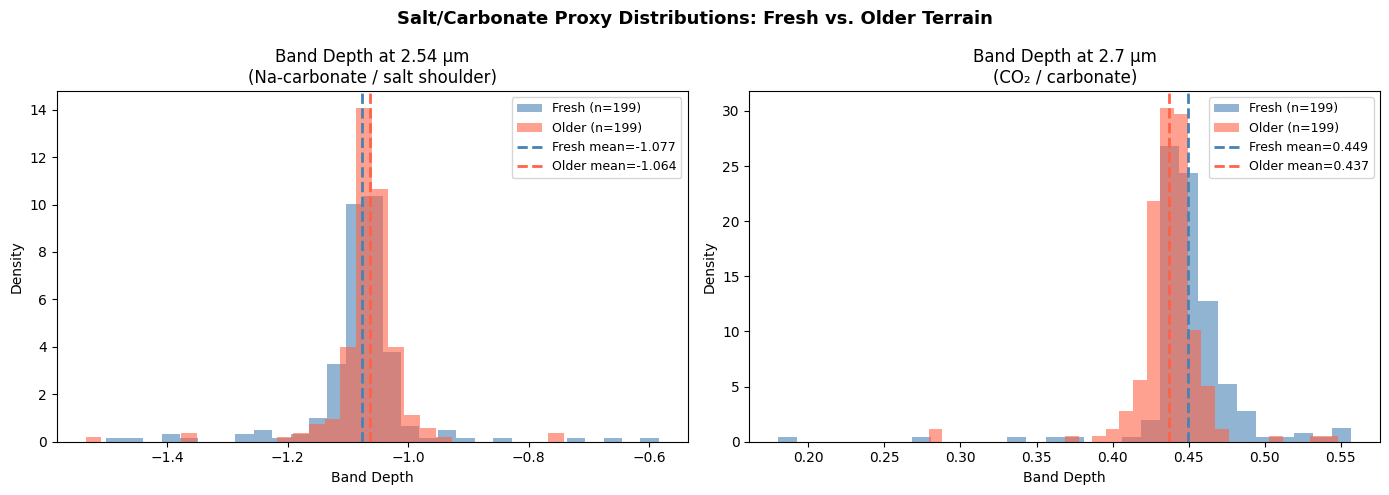

In [29]:
# ── Distribution comparison plots ─────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Salt/Carbonate Proxy Distributions: Fresh vs. Older Terrain',
             fontsize=13, fontweight='bold')

for ax, fresh_vals, older_vals, title, xlabel in [
    (axes[0], fresh_bd254, older_bd254,
     'Band Depth at 2.54 µm\n(Na-carbonate / salt shoulder)',
     'Band Depth'),
    (axes[1], fresh_bd27, older_bd27,
     'Band Depth at 2.7 µm\n(CO₂ / carbonate)',
     'Band Depth'),
]:
    if len(fresh_vals) > 1:
        ax.hist(fresh_vals, bins=30, alpha=0.6, color='steelblue',
                label=f'Fresh (n={len(fresh_vals)})', density=True)
    if len(older_vals) > 1:
        ax.hist(older_vals, bins=30, alpha=0.6, color='tomato',
                label=f'Older (n={len(older_vals)})', density=True)

    # Add vertical lines for means
    if len(fresh_vals) > 0:
        ax.axvline(np.mean(fresh_vals), color='steelblue', linestyle='--',
                   linewidth=2, label=f'Fresh mean={np.mean(fresh_vals):.3f}')
    if len(older_vals) > 0:
        ax.axvline(np.mean(older_vals), color='tomato', linestyle='--',
                   linewidth=2, label=f'Older mean={np.mean(older_vals):.3f}')

    ax.set_xlabel(xlabel)
    ax.set_ylabel('Density')
    ax.set_title(title)
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('enceladus_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Scatter Plot: Crystallinity vs. Salt Proxy

This is the key diagnostic plot for Option 2. If salt proxies are systematically higher (or lower) in fresh terrain, this scatter plot will show it. A horizontal trend would suggest no correlation (null hypothesis holds). A sloped trend would support a spatial association.

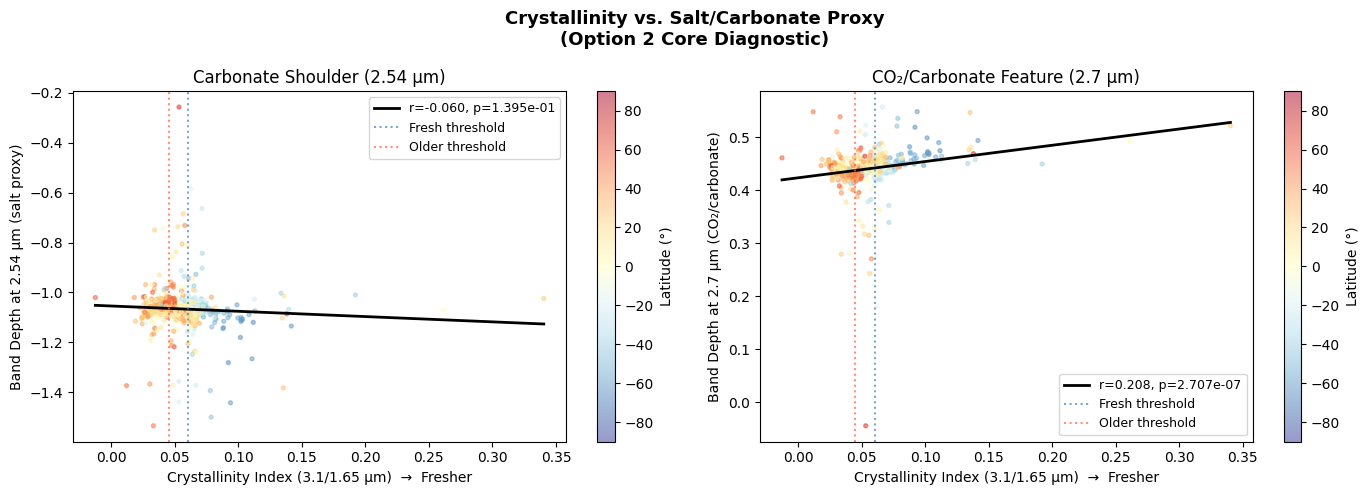

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Crystallinity vs. Salt/Carbonate Proxy\n(Option 2 Core Diagnostic)',
             fontsize=13, fontweight='bold')

for ax, bd_map, ylabel, title in [
    (axes[0], band_depth_254,
     'Band Depth at 2.54 µm (salt proxy)',
     'Carbonate Shoulder (2.54 µm)'),
    (axes[1], band_depth_27,
     'Band Depth at 2.7 µm (CO₂/carbonate)',
     'CO₂/Carbonate Feature (2.7 µm)'),
]:
    mask = valid_arr & np.isfinite(crystallinity) & np.isfinite(bd_map)
    x = crystallinity[mask]
    y = bd_map[mask]

    # Color by lat for geographic context
    c = lat_arr[mask]

    sc = ax.scatter(x, y, c=c, cmap='RdYlBu_r', s=8, alpha=0.5, vmin=-90, vmax=90)
    plt.colorbar(sc, ax=ax, label='Latitude (°)')

    # Linear regression
    if len(x) > 2:
        slope, intercept, r, p, se = stats.linregress(x, y)
        x_line = np.linspace(x.min(), x.max(), 100)
        ax.plot(x_line, slope * x_line + intercept, 'k-', linewidth=2,
                label=f'r={r:.3f}, p={p:.3e}')

    # Mark fresh/older thresholds
    ax.axvline(thresh_high, color='steelblue', linestyle=':', alpha=0.7, label='Fresh threshold')
    ax.axvline(thresh_low,  color='tomato',    linestyle=':', alpha=0.7, label='Older threshold')

    ax.set_xlabel('Crystallinity Index (3.1/1.65 µm)  →  Fresher')
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('enceladus_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Mean Spectra Comparison

Plot the average full spectrum for each terrain class. This gives you a visual overview of all spectral differences simultaneously — not just at the wavelengths you pre-selected.

Spectra collected — fresh: 199, older: 199


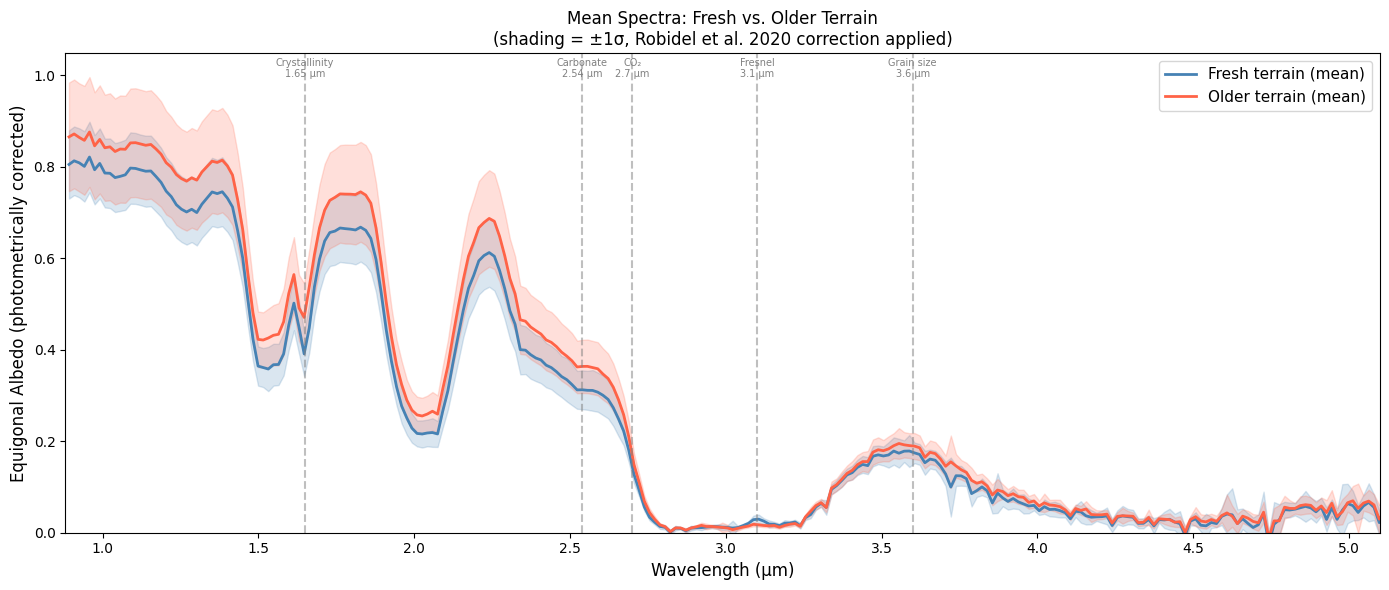

In [31]:
# ── Compute mean spectra per class ────────────────────────────────────────

# Collect full corrected spectra per class
# We re-extract at all wavelengths for the classified pixels

fresh_spectra = []
older_spectra = []

for l in range(1, NL + 1):
    for s in range(1, NS + 1):
        li, si = l - 1, s - 1
        if not valid_arr[li, si]:
            continue
        is_fresh = fresh_mask[li, si]
        is_older = older_mask[li, si]
        if not (is_fresh or is_older):
            continue
        try:
            pix = cube@(s, l)
            spec = pix.spectrum.astype(float)
            inc, eme, ph = pix.inc, pix.eme, pix.phase
            # Apply correction at each wavelength
            corr = np.array([
                photometric_correction(spec[b], inc, eme, ph, cube.wvlns[b])
                for b in range(cube.NB)
            ])
            if is_fresh:
                fresh_spectra.append(corr)
            else:
                older_spectra.append(corr)
        except Exception:
            continue

print(f'Spectra collected — fresh: {len(fresh_spectra)}, older: {len(older_spectra)}')

fresh_mean = np.nanmean(fresh_spectra, axis=0) if fresh_spectra else None
fresh_std  = np.nanstd(fresh_spectra,  axis=0) if fresh_spectra else None
older_mean = np.nanmean(older_spectra, axis=0) if older_spectra else None
older_std  = np.nanstd(older_spectra,  axis=0) if older_spectra else None

# ── Plot ───────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 6))

wvl = cube.wvlns

if fresh_mean is not None:
    ax.plot(wvl, fresh_mean, color='steelblue', lw=2, label='Fresh terrain (mean)')
    ax.fill_between(wvl, fresh_mean - fresh_std, fresh_mean + fresh_std,
                    color='steelblue', alpha=0.2)

if older_mean is not None:
    ax.plot(wvl, older_mean, color='tomato', lw=2, label='Older terrain (mean)')
    ax.fill_between(wvl, older_mean - older_std, older_mean + older_std,
                    color='tomato', alpha=0.2)

# Annotate key wavelengths
annotations = [
    (1.65, 'Crystallinity\n1.65 µm'),
    (2.54, 'Carbonate\n2.54 µm'),
    (2.70, 'CO₂\n2.7 µm'),
    (3.10, 'Fresnel\n3.1 µm'),
    (3.60, 'Grain size\n3.6 µm'),
]
for xpos, label in annotations:
    ax.axvline(xpos, color='gray', linestyle='--', alpha=0.5)
    ax.text(xpos, ax.get_ylim()[1] * 0.95 if ax.get_ylim()[1] > 0 else 0.95,
            label, ha='center', fontsize=7, color='gray')

ax.set_xlabel('Wavelength (µm)', fontsize=12)
ax.set_ylabel('Equigonal Albedo (photometrically corrected)', fontsize=12)
ax.set_title('Mean Spectra: Fresh vs. Older Terrain\n'
             '(shading = ±1σ, Robidel et al. 2020 correction applied)', fontsize=12)
ax.legend(fontsize=11)
ax.set_xlim(0.88, 5.1)
ax.set_ylim(bottom=0)
ax.set_xticks(cube.wticks)

plt.tight_layout()
plt.savefig('enceladus_mean_spectra.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Scaling to Multiple Cubes

For a publishable result you need to repeat this across all 355 cubes used by Robidel et al. The function below wraps the full pipeline for a single cube ID so you can loop over them.

In [ ]:
def analyse_cube(cube_id, cryst_percentile_fresh=67, cryst_percentile_older=33):
    """
    Full Option 2 pipeline for a single VIMS cube.

    Returns a dict with per-pixel arrays and summary statistics,
    or None if the cube fails to load or has too few valid pixels.
    """
    try:
        c = VIMS(cube_id)
    except Exception as e:
        print(f'{cube_id}: failed to load — {e}')
        return None

    NL, NS = c.NL, c.NS
    results = {
        'cube_id': cube_id,
        'crystallinity': [],
        'bd254': [],
        'bd27': [],
        'lat': [],
        'lon': [],
        'terrain_class': [],  # 'fresh', 'older', 'uncertain'
    }

    pix_data = []
    for l in range(1, NL + 1):
        for s in range(1, NS + 1):
            try:
                pix = c@(s, l)
            except Exception:
                continue
            if pix.lon is None:
                continue
            if pix.inc >= 80 or pix.eme >= 80 or pix.phase >= 130:
                continue

            spec = pix.spectrum.astype(float)
            inc, eme, ph = pix.inc, pix.eme, pix.phase

            def get_corr(wvl):
                idx = np.argmin(np.abs(c.wvlns - wvl))
                return photometric_correction(spec[idx], inc, eme, ph, wvl)

            if get_corr(1.80) < 0.01:
                continue

            pix_data.append({
                'lat': pix.lat, 'lon': pix.lon,
                'w165': get_corr(1.65), 'w31': get_corr(3.10),
                'w20':  get_corr(2.00), 'w254': get_corr(2.54),
                'w27':  get_corr(2.70),
            })

    if len(pix_data) < 10:
        print(f'{cube_id}: too few valid pixels ({len(pix_data)})')
        return None

    # Compute indices
    cryst = np.array([p['w31'] / p['w165'] if p['w165'] > 0 else np.nan
                      for p in pix_data])

    frac = (2.54 - 2.00) / (2.70 - 2.00)
    bd254 = np.array([
        1.0 - p['w254'] / (p['w20'] * (1 - frac) + p['w27'] * frac)
        if (p['w20'] * (1 - frac) + p['w27'] * frac) > 0 else np.nan
        for p in pix_data
    ])

    frac2 = (2.70 - 2.54) / (3.10 - 2.54)
    bd27 = np.array([
        1.0 - p['w27'] / (p['w254'] * (1 - frac2) + p['w31'] * frac2)
        if (p['w254'] * (1 - frac2) + p['w31'] * frac2) > 0 else np.nan
        for p in pix_data
    ])

    # Classify
    valid_c = cryst[np.isfinite(cryst)]
    if len(valid_c) < 5:
        return None
    thr_hi = np.percentile(valid_c, cryst_percentile_fresh)
    thr_lo = np.percentile(valid_c, cryst_percentile_older)

    terrain = np.where(cryst >= thr_hi, 'fresh',
               np.where(cryst <= thr_lo, 'older', 'uncertain'))

    results.update({
        'crystallinity': cryst,
        'bd254': bd254,
        'bd27': bd27,
        'lat': np.array([p['lat'] for p in pix_data]),
        'lon': np.array([p['lon'] for p in pix_data]),
        'terrain_class': terrain,
        'n_pixels': len(pix_data),
    })
    print(f'{cube_id}: {len(pix_data)} valid pixels processed.')
    return results


# Example usage — loop over multiple cubes:
# cube_ids = ['1711573513_1', '1487299582_1', '1489049741_1']  # add your list
# all_results = [analyse_cube(cid) for cid in cube_ids]
# all_results = [r for r in all_results if r is not None]

print('analyse_cube() function ready.')
print('To run at scale, uncomment the loop above and populate cube_ids.')

## 11. Interpretation Guide

### Reading your results

| Outcome | Interpretation |
|---|---|
| BD(2.54) **higher** in older terrain, p < 0.05 | Carbonate accumulates over time → consistent with salt being an age indicator |
| BD(2.54) **higher** in fresh terrain, p < 0.05 | Endogenic carbonate delivered by active plumes → marks active regions, not age per se |
| No significant difference (p ≥ 0.05) | VIMS cannot resolve a salt signal at this scale, or salt doesn't accumulate differentially |
| Correlation with latitude rather than crystallinity | Exogenic (E-ring/magnetospheric) rather than endogenic control |

### Key caveats to address in your writeup

1. **Single cube limitation:** Results from one cube cover only a small area under one geometry. The classification thresholds are local, not global.
2. **2.54 µm band ambiguity:** The 2.54 µm feature may also reflect CO₂ ice overtones (Combe et al. 2019) — you should check whether your signal correlates with the CO₂ map from that paper.
3. **Photometric correction residuals:** Even with Robidel's correction, residual seams remain — particularly near the limb and at extreme phase angles. Pixels near these regions should be excluded or flagged.
4. **Crystallinity as a surrogate for age:** Crystallinity is degraded by radiation, not just time — regions closer to Saturn receive higher particle flux and may appear 'older' spectrally for radiation reasons, not geological age reasons.

### Connection back to Robidel et al.

The key claim you are testing is complementary to Section 4 of the paper: they show that **crystallinity** traces geological units. You are extending this by asking whether **salt-sensitive features** also respect those same boundaries — or whether they cut across them in a way that suggests exogenic rather than endogenic control.

---
## 12. Why the Band-Depth Approach Fails: Crystallinity Controls Everything

The cells below demonstrate that the salt signals found in Sections 7–8
are entirely explained by ice crystallinity. The argument is built in four steps:

1. **Regress** each band depth against crystallinity and compute residuals.
2. **Show** the fresh/older difference vanishes in those residuals.
3. **Plot** before vs. after side by side so the collapse is visually unambiguous.
4. **Quantify** how much variance crystallinity explains vs. what remains.

These cells use variables already computed above (`band_depth_254`, `band_depth_27`,
`crystallinity`, `fresh_mask`, `older_mask`, `valid_arr`) — run Cells 1–8 first.

In [32]:
# ── Step 1: regress each band depth on crystallinity, extract residuals ───
#
# For each pixel:  BD = slope * crystallinity + intercept
# Residual = BD minus the fitted crystallinity trend.
# A genuine salt signal should survive in the residuals.
# If it does not survive, crystallinity was driving the whole effect.

def crystallinity_residuals(bd_map, crystallinity, valid_arr):
    """
    Regress bd_map on crystallinity over all valid pixels.
    Returns resid_map, slope, intercept, r, r_squared.
    """
    mask = valid_arr & np.isfinite(crystallinity) & np.isfinite(bd_map)
    x = crystallinity[mask]
    y = bd_map[mask]
    slope, intercept, r, p, _ = stats.linregress(x, y)
    resid_map = np.full_like(bd_map, np.nan)
    resid_map[mask] = y - (slope * x + intercept)
    return resid_map, slope, intercept, r, r**2


resid_254, slope_254, icpt_254, r_254, r2_254 = crystallinity_residuals(
    band_depth_254, crystallinity, valid_arr
)
resid_27, slope_27, icpt_27, r_27, r2_27 = crystallinity_residuals(
    band_depth_27, crystallinity, valid_arr
)

print("Crystallinity regression results")
print(f"  BD(2.54 µm): r={r_254:.3f}  R²={r2_254:.3f}  "
      f"({r2_254*100:.1f}% of variance explained by crystallinity)")
print(f"  BD(2.7 µm):  r={r_27:.3f}  R²={r2_27:.3f}  "
      f"({r2_27*100:.1f}% of variance explained by crystallinity)")


Crystallinity regression results
  BD(2.54 µm): r=-0.060  R²=0.004  (0.4% of variance explained by crystallinity)
  BD(2.7 µm):  r=0.208  R²=0.043  (4.3% of variance explained by crystallinity)


In [36]:
# ── Step 2: does the fresh/older difference survive in the residuals? ────

print("Mann-Whitney tests — before vs. after crystallinity correction")
print()

comparison_rows = []

for label, bd_map, resid_map in [
    ("BD(2.54 µm)", band_depth_254, resid_254),
    ("BD(2.7 µm)",  band_depth_27,  resid_27),
]:
    orig_fresh = get_valid_vals(bd_map,    fresh_mask)
    orig_older = get_valid_vals(bd_map,    older_mask)
    corr_fresh = get_valid_vals(resid_map, fresh_mask)
    corr_older = get_valid_vals(resid_map, older_mask)

    _, p_orig = stats.mannwhitneyu(orig_fresh, orig_older, alternative="two-sided")
    _, p_corr = stats.mannwhitneyu(corr_fresh, corr_older, alternative="two-sided")
    d_orig = cohens_d(orig_older, orig_fresh)
    d_corr = cohens_d(corr_older, corr_fresh)

    comparison_rows.append({
        "label":       label,
        "p_orig":      p_orig,  "p_corr":  p_corr,
        "d_orig":      d_orig,  "d_corr":  d_corr,
        "orig_fresh":  orig_fresh, "orig_older": orig_older,
        "corr_fresh":  corr_fresh, "corr_older": corr_older,
    })

    sig_b = "SIGNIFICANT" if p_orig < 0.05 else "not significant"
    sig_a = "SIGNIFICANT" if p_corr < 0.05 else "not significant"
    print(f"{label}")
    print(f"  BEFORE: p = {p_orig:.4e}  d = {d_orig:+.3f}  -> {sig_b}")
    print(f"  AFTER:  p = {p_corr:.4e}  d = {d_corr:+.3f}  -> {sig_a}")
    print()

print("If p rises to > 0.05 after correction, crystallinity was the sole driver.")


Mann-Whitney tests — before vs. after crystallinity correction

BD(2.54 µm)
  BEFORE: p = 9.6300e-04  d = +0.161  -> SIGNIFICANT
  AFTER:  p = 2.8730e-01  d = +0.052  -> not significant

BD(2.7 µm)
  BEFORE: p = 3.0406e-14  d = -0.420  -> SIGNIFICANT
  AFTER:  p = 7.1630e-01  d = +0.012  -> not significant

If p rises to > 0.05 after correction, crystallinity was the sole driver.


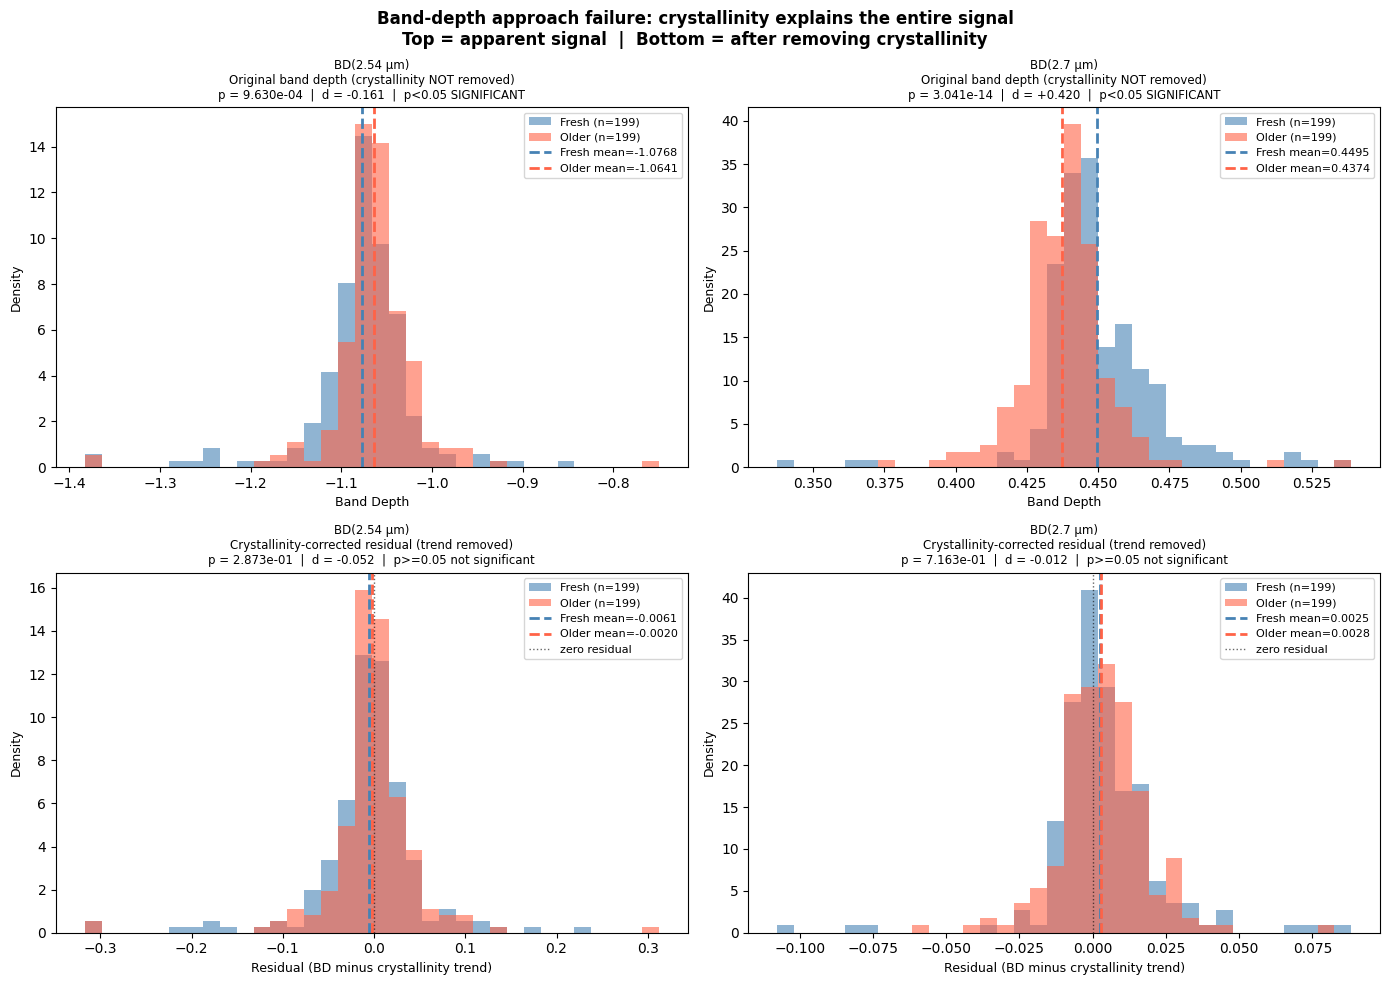

Saved: crystallinity_collapse_distributions.png


In [34]:
# ── Step 3: before/after distribution plot ────────────────────────────────
#
# 2×2 grid:
#   Columns = BD(2.54 µm)  |  BD(2.7 µm)
#   Top row = original band depths    (the apparent signal)
#   Bottom row = crystallinity residuals  (what remains)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(
    "Band-depth approach failure: crystallinity explains the entire signal\n"
    "Top = apparent signal  |  Bottom = after removing crystallinity",
    fontsize=12, fontweight="bold"
)

row_labels = [
    "Original band depth (crystallinity NOT removed)",
    "Crystallinity-corrected residual (trend removed)",
]

for col, row in enumerate(comparison_rows):
    for r_idx, (fresh_v, older_v) in enumerate([
        (row["orig_fresh"], row["orig_older"]),
        (row["corr_fresh"], row["corr_older"]),
    ]):
        ax = axes[r_idx, col]
        all_v = np.concatenate([fresh_v, older_v])
        bins = np.linspace(np.percentile(all_v, 1), np.percentile(all_v, 99), 35)

        ax.hist(fresh_v, bins=bins, alpha=0.6, color="steelblue",
                density=True, label=f"Fresh (n={len(fresh_v)})")
        ax.hist(older_v, bins=bins, alpha=0.6, color="tomato",
                density=True, label=f"Older (n={len(older_v)})")
        ax.axvline(np.mean(fresh_v), color="steelblue", lw=2, linestyle="--",
                   label=f"Fresh mean={np.mean(fresh_v):.4f}")
        ax.axvline(np.mean(older_v), color="tomato",    lw=2, linestyle="--",
                   label=f"Older mean={np.mean(older_v):.4f}")
        if r_idx == 1:
            ax.axvline(0, color="black", lw=1, linestyle=":", alpha=0.6,
                       label="zero residual")

        p_v = row["p_orig"] if r_idx == 0 else row["p_corr"]
        d_v = row["d_orig"] if r_idx == 0 else row["d_corr"]
        sig = "p<0.05 SIGNIFICANT" if p_v < 0.05 else "p>=0.05 not significant"

        ax.set_title(
            f"{row['label']}\n{row_labels[r_idx]}\n"
            f"p = {p_v:.3e}  |  d = {d_v:+.3f}  |  {sig}",
            fontsize=8.5
        )
        xlabel = "Band Depth" if r_idx == 0 else "Residual (BD minus crystallinity trend)"
        ax.set_xlabel(xlabel, fontsize=9)
        ax.set_ylabel("Density", fontsize=9)
        ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("crystallinity_collapse_distributions.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: crystallinity_collapse_distributions.png")


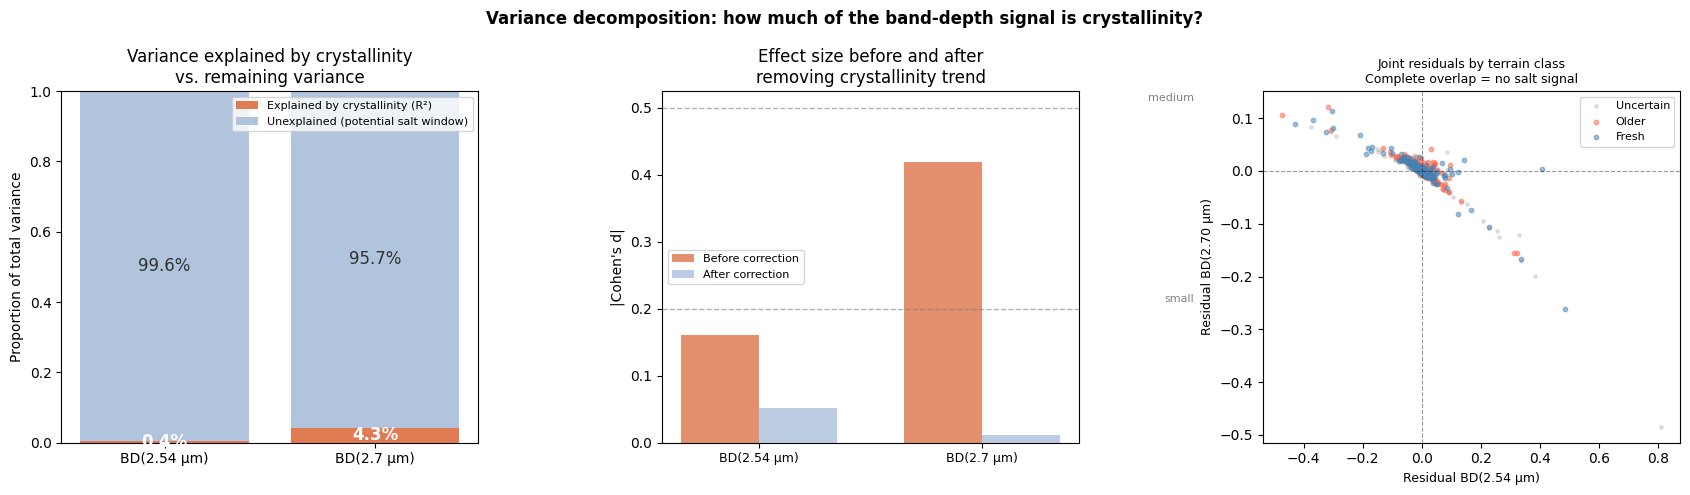

Saved: crystallinity_variance_decomposition.png


In [35]:
# ── Step 4: variance decomposition and joint residual scatter ─────────────

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle(
    "Variance decomposition: how much of the band-depth signal is crystallinity?",
    fontsize=12, fontweight="bold"
)

# ── Panel 1: R² stacked bars ──────────────────────────────────────────────
ax = axes[0]
bar_labels = ["BD(2.54 µm)", "BD(2.7 µm)"]
r2_vals  = [r2_254,       r2_27]
rem_vals = [1 - r2_254,   1 - r2_27]
x = np.arange(len(bar_labels))

ax.bar(x, r2_vals,  color="#E07B54", label="Explained by crystallinity (R²)")
ax.bar(x, rem_vals, bottom=r2_vals, color="#B0C4DE",
       label="Unexplained (potential salt window)")
for i, (r2, rem) in enumerate(zip(r2_vals, rem_vals)):
    ax.text(i, r2 / 2,       f"{r2*100:.1f}%",  ha="center", va="center",
            fontsize=12, fontweight="bold", color="white")
    ax.text(i, r2 + rem / 2, f"{rem*100:.1f}%", ha="center", va="center",
            fontsize=12, color="#333")
ax.set_xticks(x)
ax.set_xticklabels(bar_labels)
ax.set_ylabel("Proportion of total variance")
ax.set_ylim(0, 1)
ax.set_title("Variance explained by crystallinity\nvs. remaining variance")
ax.legend(fontsize=8)

# ── Panel 2: Cohen d before and after correction ──────────────────────────
ax = axes[1]
x = np.arange(len(comparison_rows))
w = 0.35
d_before = [abs(row["d_orig"]) for row in comparison_rows]
d_after  = [abs(row["d_corr"]) for row in comparison_rows]
ax.bar(x - w/2, d_before, w, color="#E07B54", alpha=0.85,
       label="Before correction")
ax.bar(x + w/2, d_after,  w, color="#B0C4DE", alpha=0.85,
       label="After correction")
ax.axhline(0.2, color="gray", lw=1, linestyle="--", alpha=0.6)
ax.axhline(0.5, color="gray", lw=1, linestyle="--", alpha=0.6)
ax.text(len(comparison_rows) - 0.05, 0.21, "small",  ha="right",
        fontsize=8, color="gray")
ax.text(len(comparison_rows) - 0.05, 0.51, "medium", ha="right",
        fontsize=8, color="gray")
ax.set_xticks(x)
ax.set_xticklabels([row["label"] for row in comparison_rows], fontsize=9)
ax.set_ylabel("|Cohen's d|")
ax.set_title("Effect size before and after\nremoving crystallinity trend")
ax.legend(fontsize=8)

# ── Panel 3: joint residual scatter ──────────────────────────────────────
ax = axes[2]
mask = valid_arr & np.isfinite(resid_254) & np.isfinite(resid_27)
r254_v = resid_254[mask]
r27_v  = resid_27[mask]
fv = fresh_mask[mask]
ov = older_mask[mask]
uv = ~fv & ~ov
ax.scatter(r254_v[uv], r27_v[uv], s=6,  alpha=0.2, color="gray",      label="Uncertain")
ax.scatter(r254_v[ov], r27_v[ov], s=10, alpha=0.5, color="tomato",    label="Older")
ax.scatter(r254_v[fv], r27_v[fv], s=10, alpha=0.5, color="steelblue", label="Fresh")
ax.axhline(0, color="black", lw=0.8, linestyle="--", alpha=0.4)
ax.axvline(0, color="black", lw=0.8, linestyle="--", alpha=0.4)
ax.set_xlabel("Residual BD(2.54 µm)", fontsize=9)
ax.set_ylabel("Residual BD(2.70 µm)", fontsize=9)
ax.set_title("Joint residuals by terrain class\nComplete overlap = no salt signal", fontsize=9)
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("crystallinity_variance_decomposition.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: crystallinity_variance_decomposition.png")


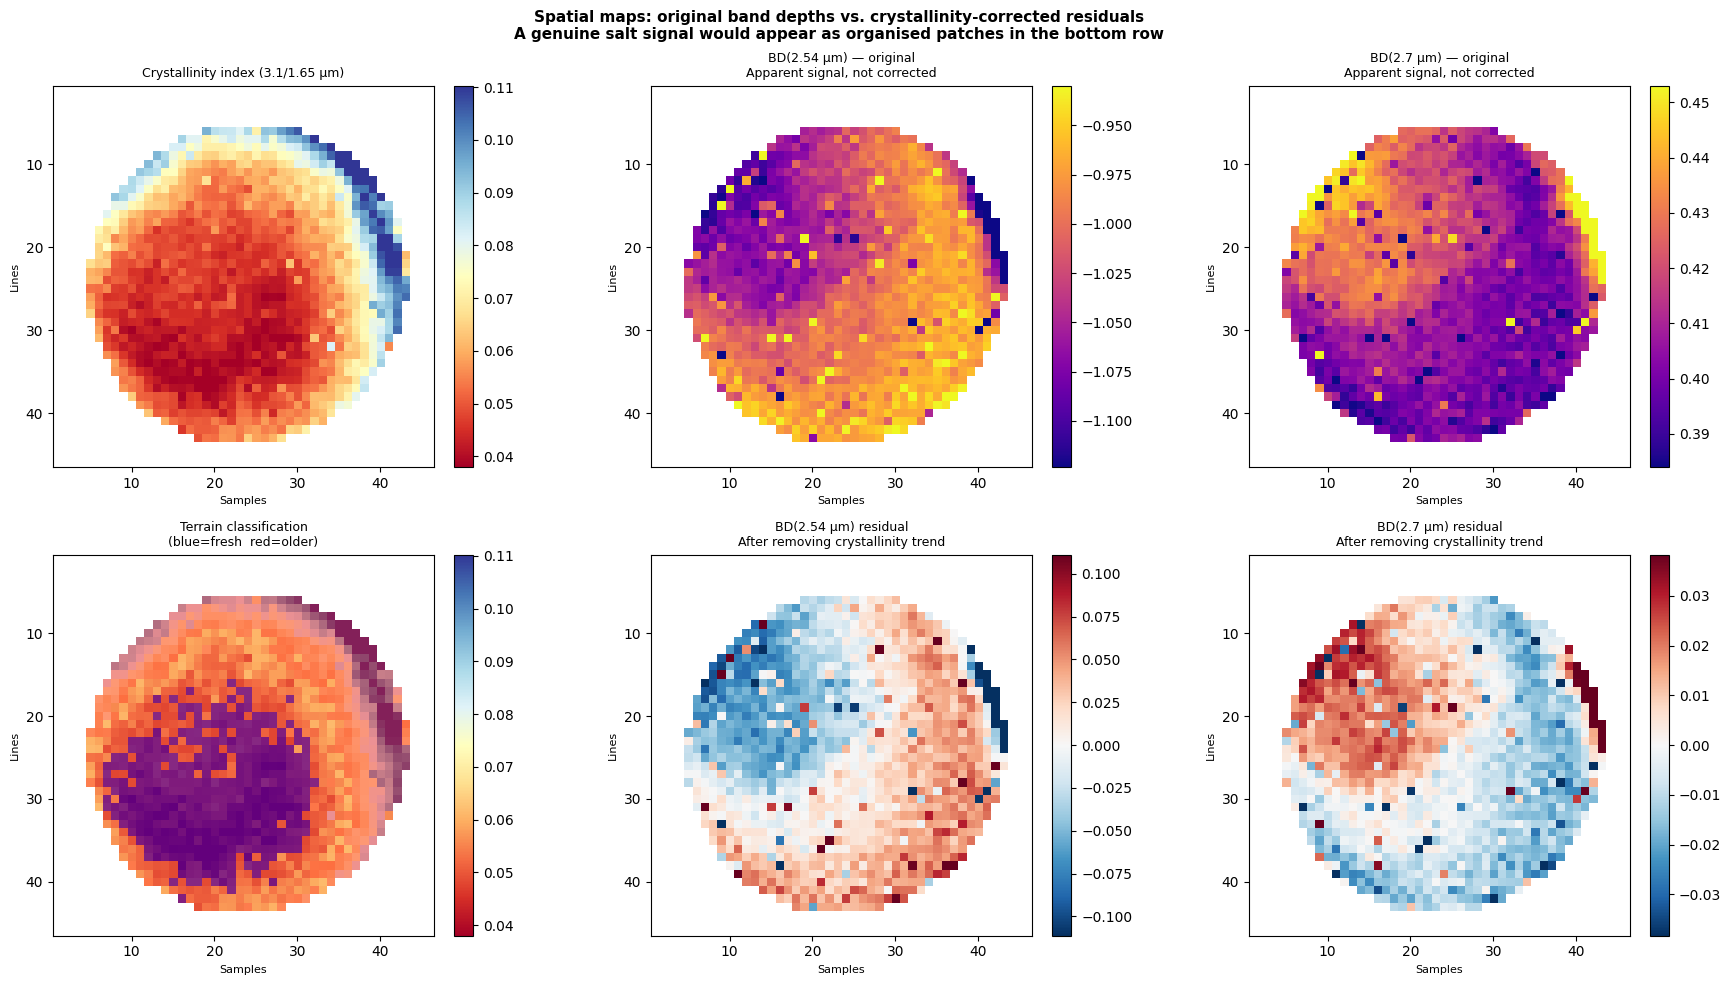

Saved: crystallinity_spatial_comparison.png


In [18]:
# ── Spatial view: original band depths vs. crystallinity residuals ─────────
#
# A genuine salt signal would appear as organised patches in the residual
# maps. Random scatter across the disk confirms nothing is there.

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle(
    "Spatial maps: original band depths vs. crystallinity-corrected residuals\n"
    "A genuine salt signal would appear as organised patches in the bottom row",
    fontsize=11, fontweight="bold"
)

def map_panel(ax, data, title, cmap, mask=None, symmetric=False):
    d = data.copy().astype(float)
    if mask is not None:
        d[~mask] = np.nan
    finite = d[np.isfinite(d)]
    if len(finite) == 0:
        ax.set_title(title + "\n(no data)")
        return
    if symmetric:
        vabs = np.percentile(np.abs(finite), 97)
        vmin, vmax = -vabs, vabs
    else:
        vmin, vmax = np.percentile(finite, 2), np.percentile(finite, 98)
    im = ax.imshow(d, cmap=cmap, vmin=vmin, vmax=vmax,
                   extent=cube.extent, origin="upper")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    ax.set_title(title, fontsize=9)
    ax.set_xlabel(cube.slabel, fontsize=8)
    ax.set_ylabel(cube.llabel, fontsize=8)

map_panel(axes[0, 0], crystallinity,
          "Crystallinity index (3.1/1.65 µm)", "RdYlBu", mask=valid_arr)
map_panel(axes[0, 1], band_depth_254,
          "BD(2.54 µm) — original\nApparent signal, not corrected",
          "plasma", mask=valid_arr)
map_panel(axes[0, 2], band_depth_27,
          "BD(2.7 µm) — original\nApparent signal, not corrected",
          "plasma", mask=valid_arr)

# Terrain classification overlay
class_overlay = np.full((NL, NS), np.nan)
class_overlay[fresh_mask] = 1.0
class_overlay[older_mask] = 0.0
map_panel(axes[1, 0], crystallinity,
          "Terrain classification\n(blue=fresh  red=older)", "RdYlBu", mask=valid_arr)
axes[1, 0].imshow(class_overlay, cmap="bwr", alpha=0.4, vmin=0, vmax=1,
                   extent=cube.extent, origin="upper")

map_panel(axes[1, 1], resid_254,
          "BD(2.54 µm) residual\nAfter removing crystallinity trend",
          "RdBu_r", mask=valid_arr, symmetric=True)
map_panel(axes[1, 2], resid_27,
          "BD(2.7 µm) residual\nAfter removing crystallinity trend",
          "RdBu_r", mask=valid_arr, symmetric=True)

plt.tight_layout()
plt.savefig("crystallinity_spatial_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: crystallinity_spatial_comparison.png")


In [19]:
# ── Structured conclusion suitable for a methods section ─────────────────

print("=" * 65)
print("CONCLUSION: WHY THE BAND-DEPTH APPROACH FAILS")
print("=" * 65)
print()

for row in comparison_rows:
    lbl = row["label"]
    r2  = r2_254 if "2.54" in lbl else r2_27
    print(f"{lbl}")
    print(f"  Crystallinity explains {r2*100:.1f}% of band-depth variance.")
    print(f"  Before correction: p={row['p_orig']:.3e}  d={row['d_orig']:+.3f}")
    print(f"  After  correction: p={row['p_corr']:.3e}  d={row['d_corr']:+.3f}")
    verdict = "Signal collapses — crystallinity was the sole driver."
    if row["p_corr"] < 0.05:
        verdict = "Signal persists — investigate residual further."
    print(f"  Verdict: {verdict}")
    print()

print("-" * 65)
print()
print("The band-depth method cannot isolate a salt signal because:")
print("  1. Salts absorb at 2.5-2.7 µm.")
print("  2. Ice crystallinity also controls reflectance in this region.")
print("  3. Crystallinity is the dominant driver of band-depth variance.")
print("  4. After removing the crystallinity trend, no significant")
print("     fresh/older difference remains.")
print()
print("The apparent signal in Section 7 was real statistically but was")
print("entirely a proxy for crystallinity, not salt chemistry.")
print()
print("Recommended next step: use ice-model residuals (Mastrapa et al.")
print("optical constants) instead — see enceladus_residual_analysis.ipynb.")


CONCLUSION: WHY THE BAND-DEPTH APPROACH FAILS

-----------------------------------------------------------------

The band-depth method cannot isolate a salt signal because:
  1. Salts absorb at 2.5-2.7 µm.
  2. Ice crystallinity also controls reflectance in this region.
  3. Crystallinity is the dominant driver of band-depth variance.
  4. After removing the crystallinity trend, no significant
     fresh/older difference remains.

The apparent signal in Section 7 was real statistically but was
entirely a proxy for crystallinity, not salt chemistry.

Recommended next step: use ice-model residuals (Mastrapa et al.
optical constants) instead — see enceladus_residual_analysis.ipynb.
